In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sachin211104/sachin-chess-project/chess_tensor.npy
/kaggle/input/datasets/sachin211104/sachin-chess-project/chess_scalar.parquet


# XGBoost model only on scaler features

Data is not balanced-
good     -     221151,
excellent  -    57825,
inaccuracy  -   28194,
mistake     -   22817,
blunder      -   7994,


Loading dataframe...

Scalar shape: (337981, 21)

========== ORIGINAL CLASS COUNTS ==========

label
good          221151
excellent      57825
inaccuracy     28194
mistake        22817
blunder         7994
Name: count, dtype: int64

Classes:

['blunder' 'excellent' 'good' 'inaccuracy' 'mistake']

Scalar feature shape:
(337981, 15)

Train shape:
(270384, 15)

Test shape:
(67597, 15)

Starting XGBoost training...


Training completed.


Models saved successfully.

Generating predictions...


Test Accuracy: 66.66%


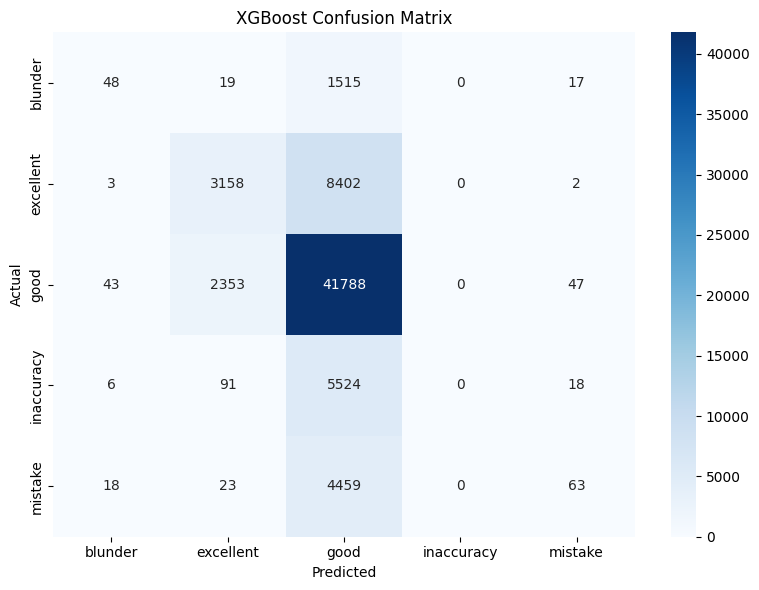


Classification Report:

              precision    recall  f1-score   support

     blunder       0.41      0.03      0.06      1599
   excellent       0.56      0.27      0.37     11565
        good       0.68      0.94      0.79     44231
  inaccuracy       0.00      0.00      0.00      5639
     mistake       0.43      0.01      0.03      4563

    accuracy                           0.67     67597
   macro avg       0.41      0.25      0.25     67597
weighted avg       0.58      0.67      0.58     67597


Top Features:

             Feature  Importance
1               turn    0.861510
8         prev_delta    0.041473
0        move_number    0.022673
7          prev_eval    0.014296
5           mobility    0.013156
10           avg_elo    0.011483
4           is_check    0.007137
6   material_balance    0.006454
3     halfmove_clock    0.005402
9           elo_diff    0.003744
2         en_passant    0.003719
11          castle_K    0.002707
12          castle_Q    0.002343
14      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


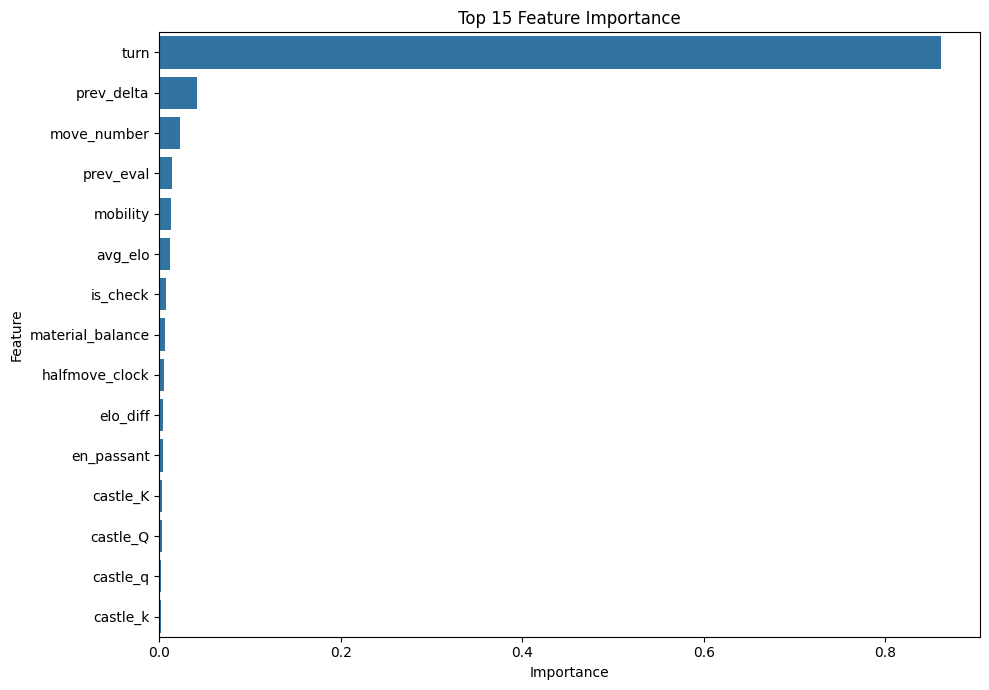


Random Prediction Samples:

   move_number          turn  en_passant  halfmove_clock      is_check  \
0    37.000000  1.000000e+00        -1.0   -1.129381e-08 -4.131128e-10   
1    26.000000 -2.828743e-09        -1.0   -1.129381e-08 -4.131128e-10   
2    41.000000  1.000000e+00        -1.0    1.000000e+00 -4.131128e-10   
3    11.999999 -2.828743e-09        -1.0   -1.129381e-08 -4.131128e-10   
4    75.000000  1.000000e+00        -1.0    1.500000e+01 -4.131128e-10   

   mobility  material_balance  prev_eval  prev_delta  elo_diff  avg_elo  \
0      38.0      2.249194e-09      196.0        20.0      -1.0   1683.5   
1      40.0     -4.000000e+00     -574.0       -92.0     227.0   1791.5   
2      37.0      1.000000e+00      161.0        21.0      -9.0   1625.5   
3      33.0      2.249194e-09      -41.0       -15.0     194.0   2198.0   
4      32.0     -5.000000e+00     -370.0        48.0     129.0   1252.5   

       castle_K      castle_Q      castle_k      castle_q      Actual  \
0 

In [4]:
# ==========================================================
# IMPORTS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf

# ==========================================================
# DATASET PATH
# ==========================================================

base_path = "/kaggle/input/datasets/sachin211104/sachin-chess-project/"

# ==========================================================
# LOAD DATA
# ==========================================================

print("\nLoading dataframe...\n")

df = pd.read_parquet(
    base_path + "chess_scalar.parquet"
)

print("Scalar shape:", df.shape)

# ==========================================================
# ORIGINAL CLASS COUNTS
# ==========================================================

print("\n========== ORIGINAL CLASS COUNTS ==========\n")

print(
    df["label"].value_counts()
)

# ==========================================================
# LABEL ENCODING
# ==========================================================

le = LabelEncoder()

y_encoded = le.fit_transform(
    df["label"]
)

y = tf.keras.utils.to_categorical(
    y_encoded
)

print("\nClasses:\n")
print(le.classes_)

# ==========================================================
# REMOVE LEAKAGE FEATURES
# ==========================================================

leak_cols = [
    "label",
    "delta",
    "eval",
    "piece_moved",
    "is_capture",
    "gives_check"
]

X_scalar = df.drop(
    columns=leak_cols
).values

print("\nScalar feature shape:")
print(X_scalar.shape)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_scalar_train, X_scalar_test, \
y_train, y_test = train_test_split(

    X_scalar,
    y,

    test_size=0.2,
    random_state=42,

    stratify=np.argmax(y, axis=1)
)

# ==========================================================
# SCALE FEATURES
# ==========================================================

scaler = StandardScaler()

X_scalar_train = scaler.fit_transform(
    X_scalar_train
)

X_scalar_test = scaler.transform(
    X_scalar_test
)

# ==========================================================
# MEMORY OPTIMIZATION
# ==========================================================

X_scalar_train = X_scalar_train.astype(
    np.float32
)

X_scalar_test = X_scalar_test.astype(
    np.float32
)

# ==========================================================
# LABELS FOR XGBOOST
# ==========================================================

y_train_labels = np.argmax(
    y_train,
    axis=1
)

y_test_labels = np.argmax(
    y_test,
    axis=1
)

print("\nTrain shape:")
print(X_scalar_train.shape)

print("\nTest shape:")
print(X_scalar_test.shape)

# ==========================================================
# BUILD XGBOOST MODEL
# ==========================================================

xgb_model = XGBClassifier(

    objective='multi:softmax',

    num_class=len(le.classes_),

    subsample=0.8,
    reg_lambda=1,
    reg_alpha=0.5,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.03,
    gamma=0.1,
    colsample_bytree=1.0,

    tree_method='hist',

    eval_metric='mlogloss',

    random_state=42,

    n_jobs=-1,

    verbosity=1
)

# ==========================================================
# TRAIN MODEL
# ==========================================================

print("\nStarting XGBoost training...\n")

xgb_model.fit(
    X_scalar_train,
    y_train_labels
)

print("\nTraining completed.\n")

# ==========================================================
# SAVE MODEL
# ==========================================================

joblib.dump(
    xgb_model,
    "/kaggle/working/xgb_scalar_no_oversampling.pkl"
)

joblib.dump(
    scaler,
    "/kaggle/working/scaler.pkl"
)

joblib.dump(
    le,
    "/kaggle/working/label_encoder.pkl"
)

print("\nModels saved successfully.")

# ==========================================================
# PREDICTIONS
# ==========================================================

print("\nGenerating predictions...\n")

y_pred = xgb_model.predict(
    X_scalar_test
)

# ==========================================================
# ACCURACY
# ==========================================================

accuracy = accuracy_score(
    y_test_labels,
    y_pred
)

print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

class_names = [
    str(cls)
    for cls in le.classes_
]

cm = confusion_matrix(
    y_test_labels,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_labels,
        y_pred,
        target_names=class_names
    )
)

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

feature_names = df.drop(
    columns=leak_cols
).columns.tolist()

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance":
    xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Features:\n")

print(
    importance_df.head(15)
)

# ==========================================================
# FEATURE IMPORTANCE PLOT
# ==========================================================

top_features = importance_df.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance")

plt.tight_layout()
plt.show()

# ==========================================================
# RANDOM TEST PREDICTIONS
# ==========================================================

random_indices = np.random.choice(
    len(y_test_labels),
    100,
    replace=False
)

actual_labels = le.inverse_transform(
    y_test_labels[random_indices]
)

predicted_labels = le.inverse_transform(
    y_pred[random_indices]
)

scalar_original = scaler.inverse_transform(
    X_scalar_test[random_indices]
)

sample_df = pd.DataFrame(
    scalar_original,
    columns=feature_names
)

sample_df["Actual"] = actual_labels
sample_df["Predicted"] = predicted_labels

sample_df["Correct"] = (
    sample_df["Actual"] ==
    sample_df["Predicted"]
)

print("\nRandom Prediction Samples:\n")

print(sample_df.head())

# ==========================================================
# SAVE RANDOM PREDICTIONS
# ==========================================================

sample_df.to_csv(
    "/kaggle/working/xgb_random_predictions.csv",
    index=False
)

# ==========================================================
# SAVE FEATURE IMPORTANCE
# ==========================================================

importance_df.to_csv(
    "/kaggle/working/xgb_feature_importance.csv",
    index=False
)

# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n================================================")
print("XGBOOST TRAINING COMPLETED")
print("================================================")